# Customer Segmentation Analysis

### Phase 2: Dimensionality Reduction and Clustering

This notebook performs the behavioral segmentation phase of our project. Building upon the preprocessed and scaled data from the exploratory data analysis (EDA) phase, we apply Principal Component Analysis (PCA) to reduce dimensionality and utilize K-Means clustering to identify distinct customer segments.

In [1]:
import pandas as pd
import json

# Load the saved preprocessed files instantly from the folder
customer_info_processed = pd.read_csv('customer_info_processed.csv')
customer_info_scaled = pd.read_csv('customer_info_scaled.csv')

# Load the feature columns list
with open('feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

print(f"-> Inherited Scaled Data Shape: {customer_info_scaled.shape}")

-> Inherited Scaled Data Shape: (33038, 23)


## 1. Dimensionality Reduction via PCA
To optimize our clustering performance, we first apply Principal Component Analysis (PCA). By targeting a variance threshold of 90%, we compress the original feature set into a smaller number of principal components. This step is crucial for:
* **Noise Reduction:** Filtering out less significant variations in the dataset.
* **Clustering Stability:** Reducing the "curse of dimensionality" which can make distance calculations in K-Means less effective.


In [2]:
import importlib
import segmentation

# Force Jupyter to refresh and re-read external file from the disk
importlib.reload(segmentation)

# Pull the functions into notebook workspace
from segmentation import run_pca, get_clustering_metrics, apply_final_clustering

print("✅ External functions imported flawlessly with cache protection active!")

✅ External functions imported flawlessly with cache protection active!


## 2. Optimal K Selection: The Elbow Method


1. Dimensionality Reduction: Features compressed to 15 PCA components.


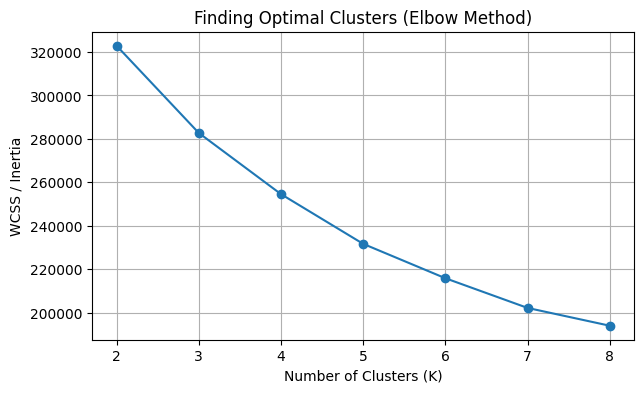

In [3]:
import matplotlib.pyplot as plt

# 1. Compress features using PCA function
pca_data, pca_model = run_pca(customer_info_scaled[feature_cols])
print(f"1. Dimensionality Reduction: Features compressed to {pca_model.n_components_} PCA components.")

# 2. Extract clustering performance metrics
k_range, wcss, silhouette = get_clustering_metrics(pca_data)

# 3. Generate the Elbow curve plot 
plt.figure(figsize=(7, 4))
plt.plot(k_range, wcss, 'o-')
plt.title('Finding Optimal Clusters (Elbow Method)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.grid(True)
plt.show()



The plot above displays the relationship between the number of clusters ($K$) and the **Within-Cluster Sum of Squares (WCSS)**. 

### Interpretation:
* **The Slope Change:** We observe a sharp decline in WCSS as we move from 2 to 4 clusters.
* **The Elbow Point:** The "elbow" or inflection point is most visible at **$K = 5$**. At this point, the rate of improvement in WCSS begins to level off significantly.
* **Selection:** Choosing $K = 5$ provides a balanced model that captures the primary segments in our data without over-partitioning the customer base into redundant groups.

### Silhouette Score Analysis
The silhouette score measures how well each point fits its assigned cluster vs neighbouring clusters. Higher is better (max=1.0).

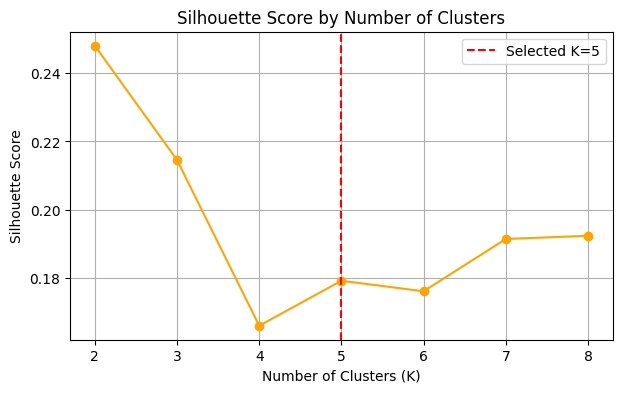

Silhouette score at K=5: 0.1792


In [4]:
plt.figure(figsize=(7, 4))
plt.plot(k_range, silhouette, 'o-', color='orange')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.axvline(x=5, color='red', linestyle='--', label='Selected K=5')
plt.legend()
plt.grid(True)
plt.show()

print(f"Silhouette score at K=5: {silhouette[k_range.index(5) if hasattr(k_range, 'index') else list(k_range).index(5)]:.4f}")

### Note on K Selection
The silhouette score peaks at K=2, however a two-cluster solution is too broad to be 
actionable from a marketing perspective. K=5 is selected based on the elbow curve's 
inflection point, and produces five distinct, interpretable segments with meaningful 
differences in spend behaviour, family composition, and product preferences.

## 3. Final Results and Export
With $K = 5$ identified as the optimal cluster count, the final model has been applied to the PCA-transformed data. 


In [5]:
# 4. Generate final cluster assignments 
final_df = apply_final_clustering(pca_data, customer_info_processed, k=5)

# 5. save submission CSV
submission = final_df[['customer_id', 'cluster']]
submission.to_csv('proposed_clusters.csv', index=False)

print(f"\n 'proposed_clusters.csv' successfully generated with {len(submission)} customer assignments.")


 'proposed_clusters.csv' successfully generated with 33038 customer assignments.


### Deliverables
* **Cluster Assignments:** Each customer has been assigned a unique segment ID (0-4).
* **Export:** The results have been saved to **`proposed_clusters.csv`**, containing the required `customer_id` and `cluster` columns for final submission and evaluation.

## 4. Customer Segment Profiling & Interpretation

With our final $K=5$ KMeans model successfully applied, we map the cluster labels back to our original, unscaled dataset. 
This allows us to calculate the average values of our real-world features (such as age, income, and spending metrics) for each distinct group.

#### Objective
By aggregating the data by cluster, we can move past abstract cluster numbers ($0, 1, 2, 3, 4$) and define concrete customer personas based on their behavioral and demographic patterns.

In [6]:
# 1. Identify all numeric columns to average out (excluding IDs)
numeric_cols = final_df.select_dtypes(include=['number']).columns
if 'customer_id' in numeric_cols:
    numeric_cols = numeric_cols.drop('customer_id')

# 2. Calculate the average metrics for each of 5 clusters
cluster_profiles = final_df.groupby('cluster')[numeric_cols].mean()

# 3. Display the profiling table beautifully
print("📊 CUSTOMER SEGMENT PROFILES (MEAN VALUES):")
display(cluster_profiles.round(2))

# 4. Print out the size of each cluster to see group distributions
print("\n👥 CUSTOMER COUNT PER CLUSTER:")
print(final_df['cluster'].value_counts().sort_index())

📊 CUSTOMER SEGMENT PROFILES (MEAN VALUES):


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,total_spend,age,has_loyalty_card,cluster
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.48,0.25,0.32,1.03,1.49,8625.54,6737.01,17.40,193.33,543.46,...,273.98,704.06,302.01,107.14,0.26,2017.53,23629.81,55.18,0.47,0.0
1,0.51,1.03,0.89,0.69,3.36,11460.28,1443.03,12.37,1718.79,507.32,...,1289.33,176.97,333.99,103.26,0.12,2015.61,17474.08,57.06,0.58,1.0
2,0.49,0.91,0.64,0.99,3.29,12484.94,1042.86,12.05,430.17,280.93,...,579.39,189.03,328.15,117.75,0.44,2015.90,16918.88,51.34,0.59,2.0
3,0.51,1.01,1.01,1.05,3.69,30258.71,3291.47,12.77,430.39,662.99,...,1094.22,318.36,363.22,244.83,0.35,2012.84,43286.31,58.38,0.74,3.0
4,0.51,3.72,2.83,0.93,3.19,24380.16,4965.38,10.12,830.99,810.02,...,909.19,401.17,358.65,302.60,0.21,2013.30,37295.11,56.83,0.67,4.0



👥 CUSTOMER COUNT PER CLUSTER:
cluster
0     3538
1     7219
2    14316
3     5203
4     2762
Name: count, dtype: int64


## 5. Basket Analysis & Targeted Promotions

Using the `customer_basket` dataset, we mine association rules per cluster to identify 
product affinities. These rules directly inform our targeted promotion strategy for each segment.

In [7]:
importlib.reload(segmentation)
from segmentation import load_basket_data, get_cluster_rules, get_top_products_per_cluster

basket_df = load_basket_data('customer_basket.csv')

# Build a lightweight cluster lookup table from final_df
customer_clusters = final_df[['customer_id', 'cluster']].copy()

print(f"Basket data loaded: {len(basket_df)} transactions")
print(f"Unique customers in basket data: {basket_df['customer_id'].nunique()}")

Basket data loaded: 100000 transactions
Unique customers in basket data: 28127


### 5.1 Top Products per Cluster

In [8]:
print("🛒 TOP 10 PRODUCTS PER CLUSTER\n")
for cluster_id in sorted(final_df['cluster'].unique()):
    print(f"--- Cluster {cluster_id} ---")
    top_products = get_top_products_per_cluster(basket_df, customer_clusters, cluster_id, top_n=10)
    print(top_products.to_string())
    print()

🛒 TOP 10 PRODUCTS PER CLUSTER

--- Cluster 0 ---
list_of_goods
shampoo              2973
toothpaste           2968
deodorant            2954
shower gel           2950
tooth brush          2904
energy bar           2143
protein bar          2086
body spray           1851
antioxydant juice    1814
toilet paper         1802

--- Cluster 1 ---
list_of_goods
dog food        5049
babies food     4694
napkins         4327
cooking oil     4189
cat food        3474
chicken         3364
toilet paper    3227
cereals         3204
milk            3066
fresh bread     2964

--- Cluster 2 ---
list_of_goods
asparagus               6660
airpods                 6052
spinach                 4144
tomatoes                4119
carrots                 3906
avocado                 3532
bluetooth headphones    3526
energy drink            3456
salad                   3407
green beans             3004

--- Cluster 3 ---
list_of_goods
asparagus      2080
airpods        1795
fresh bread    1751
cereals        161

### 5.2 Association Rules (min_support=0.02, min_confidence=0.2, ranked by lift)

In [9]:
print("🔗 TOP ASSOCIATION RULES PER CLUSTER\n")

cluster_rules = {}
for cluster_id in sorted(final_df['cluster'].unique()):
    rules = get_cluster_rules(basket_df, customer_clusters, cluster_id, min_support=0.02, min_confidence=0.2)
    cluster_rules[cluster_id] = rules

    print(f"--- Cluster {cluster_id} (top 5 rules by lift) ---")
    if rules.empty:
        print("  No rules found.")
    else:
        top5 = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5)
        display(top5)
    print()

🔗 TOP ASSOCIATION RULES PER CLUSTER

--- Cluster 0 (top 5 rules by lift) ---


,antecedents,consequents,support,confidence,lift
0,(airpods),(bluetooth headphones),0.041436,0.288358,3.521945
1,(bluetooth headphones),(airpods),0.041436,0.506089,3.521945
2,(energy drink),(bluetooth headphones),0.028141,0.286359,3.497526
3,(bluetooth headphones),(energy drink),0.028141,0.343708,3.497526
4,(airpods),(energy drink),0.045867,0.319198,3.248120



--- Cluster 1 (top 5 rules by lift) ---


,antecedents,consequents,support,confidence,lift
0,(napkins),(cooking oil),0.041144,0.296279,2.203811
1,(cooking oil),(napkins),0.041144,0.306040,2.203811
2,(babies food),(cooking oil),0.041593,0.276097,2.053691
3,(cooking oil),(babies food),0.041593,0.309382,2.053691
4,(napkins),(babies food),0.042781,0.308066,2.044955



--- Cluster 2 (top 5 rules by lift) ---


,antecedents,consequents,support,confidence,lift
0,(salad),(avocado),0.026183,0.281479,2.918953
1,(avocado),(salad),0.026183,0.271518,2.918953
2,(energy drink),(bluetooth headphones),0.025446,0.269676,2.801310
3,(bluetooth headphones),(energy drink),0.025446,0.264322,2.801310
4,(salad),(carrots),0.026565,0.285588,2.677995



--- Cluster 3 (top 5 rules by lift) ---


,antecedents,consequents,support,confidence,lift
0,(cereals),(eggs),0.027989,0.260870,2.595894
1,(eggs),(cereals),0.027989,0.278515,2.595894
2,(butter),(eggs),0.027322,0.260152,2.588757
3,(eggs),(butter),0.027322,0.271883,2.588757
4,(butter),(cereals),0.026856,0.255711,2.383350



--- Cluster 4 (top 5 rules by lift) ---


,antecedents,consequents,support,confidence,lift
0,(green tea),"(cereals, eggs)",0.023466,0.206009,1.346296
1,"(green tea, eggs)",(cereals),0.023466,0.489796,1.307934
2,"(green tea, cereals)",(eggs),0.023466,0.466019,1.292532
3,"(cereals, milk)",(oatmeal),0.022977,0.276471,1.286005
4,"(cereals, chocolate bread)",(eggs),0.026399,0.457627,1.269256


### 5.3 Targeted Promotions

In [10]:
print("🎯 TARGETED PROMOTION SUGGESTIONS PER CLUSTER\n")

for cluster_id in sorted(final_df['cluster'].unique()):
    rules = cluster_rules[cluster_id]
    profile = cluster_profiles.loc[cluster_id]

    print(f"=== Cluster {cluster_id} ===")

    if not rules.empty:
        # Take the top rule by lift
        top_rule = rules.iloc[0]
        antecedent = ', '.join(list(top_rule['antecedents']))
        consequent = ', '.join(list(top_rule['consequents']))
        print(f"  Top association: [{antecedent}] → [{consequent}]  (lift={top_rule['lift']:.2f})")
        print(f"  💡 Suggested promotion: Buy {antecedent}, get 20% off {consequent}!")
    
    # Add a spend-based promotion hint using cluster profile
    top_category = profile[[
    'lifetime_spend_electronics',
    'lifetime_spend_vegetables', 'lifetime_spend_meat',
    'lifetime_spend_fish', 'lifetime_spend_hygiene',
    'lifetime_spend_petfood', 'lifetime_spend_videogames'
]].idxmax().replace('lifetime_spend_', '')
    
    print(f"  🏆 Highest spend category: {top_category}")
    print(f"  💡 Suggested promotion: Double loyalty points on all {top_category} purchases this month!")
    print()

🎯 TARGETED PROMOTION SUGGESTIONS PER CLUSTER

=== Cluster 0 ===
  Top association: [airpods] → [bluetooth headphones]  (lift=3.52)
  💡 Suggested promotion: Buy airpods, get 20% off bluetooth headphones!
  🏆 Highest spend category: electronics
  💡 Suggested promotion: Double loyalty points on all electronics purchases this month!

=== Cluster 1 ===
  Top association: [napkins] → [cooking oil]  (lift=2.20)
  💡 Suggested promotion: Buy napkins, get 20% off cooking oil!
  🏆 Highest spend category: vegetables
  💡 Suggested promotion: Double loyalty points on all vegetables purchases this month!

=== Cluster 2 ===
  Top association: [salad] → [avocado]  (lift=2.92)
  💡 Suggested promotion: Buy salad, get 20% off avocado!
  🏆 Highest spend category: electronics
  💡 Suggested promotion: Double loyalty points on all electronics purchases this month!

=== Cluster 3 ===
  Top association: [cereals] → [eggs]  (lift=2.60)
  💡 Suggested promotion: Buy cereals, get 20% off eggs!
  🏆 Highest spend cat

## 6. Cluster Naming & Visualization

Based on the profiling analysis, we assign each cluster a descriptive persona name.

In [11]:
import numpy as np

# Cluster names based on profiling
cluster_names = {
    0: 'Tech & Hygiene Buyers',  
    1: 'Young Families',           
    2: 'Promo Hunters',           
    3: 'Premium Loyalists',        
    4: 'Heavy Explorers'           
}

final_df['cluster_name'] = final_df['cluster'].map(cluster_names)

print("Cluster name mapping:")
for k, v in cluster_names.items():
    count = (final_df['cluster'] == k).sum()
    print(f"  Cluster {k} → {v}  ({count} customers)")

Cluster name mapping:
  Cluster 0 → Casual Shoppers  (3538 customers)
  Cluster 1 → Minimal Buyers  (7219 customers)
  Cluster 2 → Promo Hunters  (14316 customers)
  Cluster 3 → Premium Loyalists  (5203 customers)
  Cluster 4 → Heavy Explorers  (2762 customers)


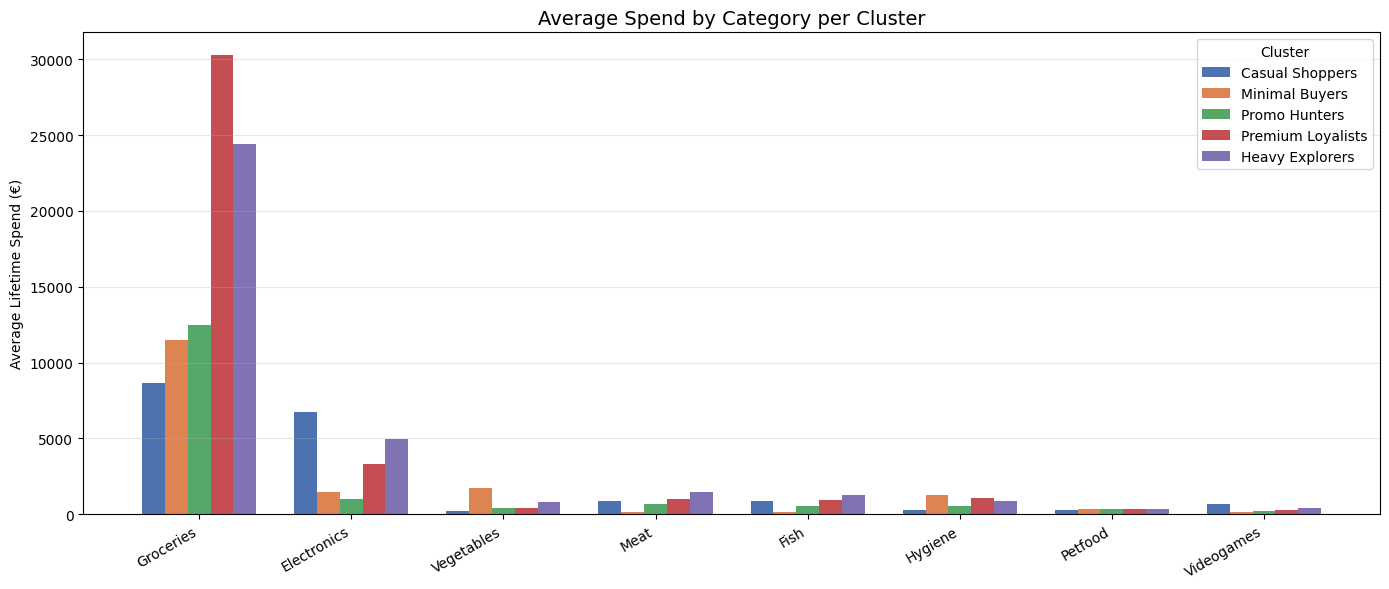

In [12]:
spend_cols = [
    'lifetime_spend_groceries', 'lifetime_spend_electronics',
    'lifetime_spend_vegetables', 'lifetime_spend_meat',
    'lifetime_spend_fish', 'lifetime_spend_hygiene',
    'lifetime_spend_petfood', 'lifetime_spend_videogames'
]

# Clean up label names for display
labels = [c.replace('lifetime_spend_', '').replace('_', ' ').title() for c in spend_cols]

# Get mean spend per cluster for these categories
spend_profile = cluster_profiles[spend_cols].copy()
spend_profile.index = [cluster_names[i] for i in spend_profile.index]

x = np.arange(len(labels))
width = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (cluster_name, row) in enumerate(spend_profile.iterrows()):
    ax.bar(x + i * width, row.values, width, label=cluster_name, color=colors[i])

ax.set_title('Average Spend by Category per Cluster', fontsize=14)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Average Lifetime Spend (€)')
ax.legend(title='Cluster')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

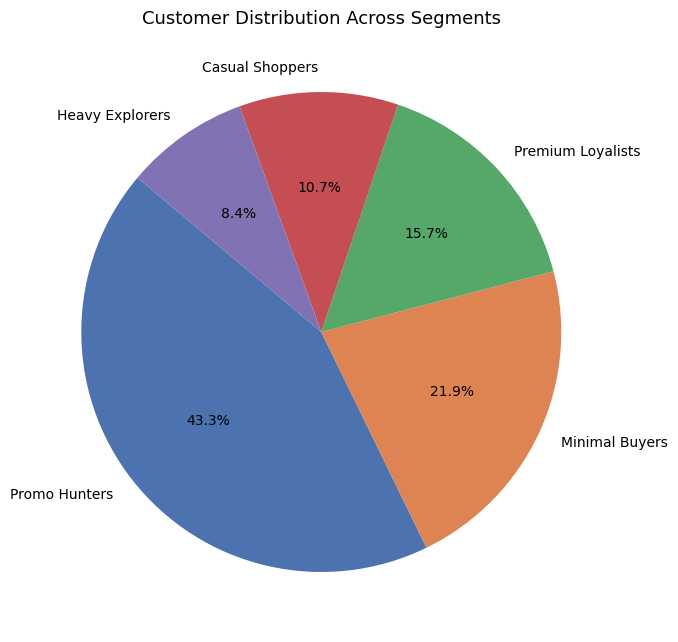

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))
sizes = final_df['cluster_name'].value_counts()
ax.pie(
    sizes,
    labels=sizes.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
ax.set_title('Customer Distribution Across Segments', fontsize=13)
plt.tight_layout()
plt.show()